# GAP-Subgraph-Driven Attacker Demo

**Date**: 2026-04-22
**Branch**: `feat/attacker-profiling`
**Purpose**: Demonstrate that feeding a different GAP subgraph to the attacker produces measurably different simulator behaviour.

## What changed

- New `SubgraphAttackerProfile` wraps an `AttackerProfile` with a MITRE ATT&CK technique pool
  restricted to a subgraph of the Generalised Attack Profile (GAP). Per-phase sampling draws
  techniques from that pool weighted by campaign frequency.
- `AttackOperation` dispatches a technique at each of the six phase entries and records it in the
  attack-stats `technique_id` column. Legacy `AttackerProfile.default()` runs emit `None` there,
  so existing analysis is unaffected.
- An `EventLogger` sidecar captures phase / compromise / MTD events for the replay visualiser.

## Open question for the supervisor meeting

*Tactic-level vs technique-level agent-visible action space* — the attacker now samples at the
technique level, but the DDQN defender still observes the aggregated six-phase signal. Widening
that observation is the next architectural decision.


In [1]:
# If mitreattack-python is missing from the env, fall through; we only need it for the
# fallback STIX path. The committed GAP artefact covers the primary path.
try:
    import mitreattack  # noqa: F401
except ImportError:
    %pip install -q mitreattack-python

In [2]:
from pathlib import Path
import sys, json, random, warnings, logging

src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from IPython.display import HTML
import networkx as nx
import simpy

from mtdsim.attacker.gap import (
    GeneralisedAttackProfile, TerminalObjectiveSelector, TACTIC_ORDER,
)
from mtdsim.attacker.gap.viz.theme import TACTIC_PALETTE
from mtdsim.attacker import Adversary, AttackOperation, AttackerProfile
from mtdsim.attacker.subgraph_profile import SubgraphAttackerProfile
from mtdsim.stats.event_log import EventLogger
from mtdsim.network.time_network import TimeNetwork
from mtdsim.data import constants

print("imports ok")

imports ok


## 1. Load GAP artefact

Uses the committed `data/gap/gap_v0.4_latest.json` so the notebook runs offline. If you need to
rebuild, see the 2026-04-08 GAP build notebook.

In [3]:
GAP_PATH = Path("../data/gap/gap_v0.4_latest.json")
with open(GAP_PATH) as f:
    gap_data = json.load(f)
gap = GeneralisedAttackProfile.from_dict(gap_data)
print(f"GAP v{gap.version} ({gap.build_date})")
print(f"  nodes: {len(gap.nodes)}, edges: {len(gap.edges)}, objectives: {len(gap.objective_nodes)}")

GAP v0.4 (2026-04-19)
  nodes: 216, edges: 383, objectives: 31


## 2. Pick two subgraphs

Strategy A terminal-objective cones:

- **Subgraph A (ransomware)**: ancestors of T1486 — Data Encrypted for Impact.
- **Subgraph B (cloud exfil)**: ancestors of T1567 — Exfiltration Over Web Service.

Fallbacks if either has fewer than 5 ancestors in the current GAP: T1657 and T1020.

In [4]:
def _pick_with_fallback(primary, fallback, label):
    sel = TerminalObjectiveSelector(technique=primary).select(gap)
    if len(sel.node_set) >= 5:
        return sel, primary
    sel = TerminalObjectiveSelector(technique=fallback).select(gap)
    print(f"{label}: falling back from {primary} to {fallback} (size was {len(sel.node_set)})")
    return sel, fallback

view_a, tid_a = _pick_with_fallback("T1486", "T1657", "ransomware")
view_b, tid_b = _pick_with_fallback("T1567", "T1020", "cloud exfil")

print(f"A ransomware cone  {tid_a}: {len(view_a.node_set)} nodes, {len(view_a.edge_set)} edges")
print(f"B cloud-exfil cone {tid_b}: {len(view_b.node_set)} nodes, {len(view_b.edge_set)} edges")

# Tactic coverage
def _tactic_counts(view):
    return pd.Series(
        [gap.nodes[t].primary_tactic for t in view.node_set if t in gap.nodes]
    ).value_counts()

cov = pd.concat(
    [_tactic_counts(view_a).rename("A (ransomware)"),
     _tactic_counts(view_b).rename("B (cloud exfil)")],
    axis=1,
).fillna(0).astype(int)
cov = cov.reindex(TACTIC_ORDER).fillna(0).astype(int)
cov

A ransomware cone  T1486: 92 nodes, 260 edges
B cloud-exfil cone T1567: 88 nodes, 230 edges


,A (ransomware),B (cloud exfil)
reconnaissance,5,5
resource-development,4,4
initial-access,7,7
execution,7,6
persistence,11,11
privilege-escalation,4,4
defense-evasion,11,9
credential-access,6,6
discovery,16,16
lateral-movement,5,5


## 3. Build two `SubgraphAttackerProfile` instances

Each wraps `AttackerProfile.default()`, so the simulator's scalar parameters are held constant —
every behavioural difference at runtime comes from the restricted technique pool.

In [5]:
profile_a = SubgraphAttackerProfile.from_subgraph_view(
    view_a, gap, AttackerProfile.default(), selector_tag=f"ransomware:{tid_a}",
)
profile_b = SubgraphAttackerProfile.from_subgraph_view(
    view_b, gap, AttackerProfile.default(), selector_tag=f"cloud-exfil:{tid_b}",
)

# Delegation spot-check
for p in (profile_a, profile_b):
    assert p.exploit_success_bonus == AttackerProfile.default().exploit_success_bonus
    assert p.brute_force_multiplier == AttackerProfile.default().brute_force_multiplier

print("profile A:", profile_a.selector_tag, "| nodes:", len(profile_a.subgraph_nodes))
print("profile B:", profile_b.selector_tag, "| nodes:", len(profile_b.subgraph_nodes))

profile A: ransomware:T1486 | nodes: 92
profile B: cloud-exfil:T1567 | nodes: 88


## 4. Paired simulations

Three seeds keeps the notebook under ~5 minutes. Bump `SEEDS` if time permits. Primary
comparison is `no_mtd` to isolate the attacker; a second `random`-MTD run supports the MTTC
panel.

In [6]:
import time
from tqdm.auto import tqdm

NETWORK_PARAMS = dict(
    total_nodes=30, total_endpoints=3, total_subnets=6, total_layers=3, total_database=1,
    terminate_compromise_ratio=0.8,
)
FINISH_TIME = 5000
SEEDS = [42, 123, 456]

EVENTS_DIR = Path("gap_out/events")
EVENTS_DIR.mkdir(parents=True, exist_ok=True)


def run_single(profile, scheme, seed, tag):
    random.seed(seed)
    np.random.seed(seed)
    t_init0 = time.perf_counter()
    env = simpy.Environment()
    end_event = env.event()
    net = TimeNetwork(**NETWORK_PARAMS)
    t_init = time.perf_counter() - t_init0
    adv = Adversary(net, constants.ATTACKER_THRESHOLD, profile)
    evlog = EventLogger(env)
    evlog.emit("sim_started", t=0.0, profile=getattr(profile, "selector_tag", "default"),
               scheme=scheme, seed=seed)
    attack_op = AttackOperation(env, end_event, adv, event_logger=evlog)
    attack_op.proceed_attack()
    if scheme == "random":
        from mtdsim.defender.mtd_operation import MTDOperation
        from mtdsim.stats.security_metric_statistics import SecurityMetricStatistics
        mtd = MTDOperation(SecurityMetricStatistics(), env, end_event, net, attack_op,
                           scheme="random", adversary=adv, event_logger=evlog)
        mtd.proceed_mtd()
    t_sim0 = time.perf_counter()
    env.run(until=FINISH_TIME)
    t_sim = time.perf_counter() - t_sim0
    evlog.emit("sim_ended",
               compromise_ratio=len(adv.get_compromised_hosts()) / NETWORK_PARAMS["total_nodes"])
    df = adv.get_statistics()
    df = df.assign(profile=tag, scheme=scheme, seed=seed)
    evlog.to_jsonl(str(EVENTS_DIR / f"{tag}_{scheme}_{seed}.jsonl"))
    return df, evlog.events, t_init, t_sim


runs = [(prof, tag, scheme, s)
        for prof, tag in [(profile_a, "A"), (profile_b, "B")]
        for scheme in ("no_mtd", "random")
        for s in SEEDS]

frames = []
event_logs = {}
pbar = tqdm(runs, desc="paired sims")
for prof, tag, scheme, s in pbar:
    pbar.set_postfix_str(f"{tag}/{scheme}/seed={s}")
    df, events, t_init, t_sim = run_single(prof, scheme, s, tag)
    frames.append(df)
    event_logs[(tag, scheme, s)] = events
    pbar.write(f"{tag}/{scheme}/seed={s}: init={t_init:.1f}s sim={t_sim:.1f}s "
               f"rows={len(df)} events={len(events)}")

stats = pd.concat(frames, ignore_index=True)
print("rows:", len(stats))
print("runs:", stats.groupby(["profile", "scheme", "seed"]).size().shape[0])
stats.head()


paired sims:   0%|          | 0/12 [00:00<?, ?it/s]

A/no_mtd/seed=42: init=0.1s sim=0.0s rows=549 events=797
A/no_mtd/seed=123: init=0.1s sim=0.0s rows=621 events=815
A/no_mtd/seed=456: init=0.1s sim=0.1s rows=544 events=754
A/random/seed=42: init=0.1s sim=0.1s rows=554 events=812
A/random/seed=123: init=0.1s sim=0.1s rows=606 events=848
A/random/seed=456: init=0.1s sim=0.1s rows=581 events=845
B/no_mtd/seed=42: init=0.1s sim=0.0s rows=549 events=797
B/no_mtd/seed=123: init=0.1s sim=0.0s rows=621 events=815
B/no_mtd/seed=456: init=0.1s sim=0.0s rows=544 events=754
B/random/seed=42: init=0.1s sim=0.1s rows=554 events=812
B/random/seed=123: init=0.1s sim=0.1s rows=606 events=848
B/random/seed=456: init=0.1s sim=0.1s rows=581 events=845
rows: 6910
runs: 12


,name,start_time,finish_time,duration,current_host,current_host_uuid,compromise_host,compromise_host_uuid,current_host_attempt,cumulative_attempts,cumulative_compromised_hosts,compromise_users,interrupted_in,interrupted_by,technique_id,profile,scheme,seed
0,SCAN_HOST,0.000000,5.000000,5.000000,-1,-1,None,None,0,0,0,[],None,None,T1016,A,no_mtd,42
1,ENUM_HOST,5.000000,10.000000,5.000000,-1,-1,None,None,0,0,0,[],None,None,T1583,A,no_mtd,42
2,SCAN_PORT,10.000000,35.000000,25.000000,0,0c2366d0-0c5d-47b1-8d5b-3e18815e542c,None,None,1,0,0,[],None,None,T1189,A,no_mtd,42
3,EXPLOIT_VULN,35.000000,36.122228,1.122228,0,0c2366d0-0c5d-47b1-8d5b-3e18815e542c,None,None,1,0,0,[],None,None,T1547,A,no_mtd,42
4,EXPLOIT_VULN,36.122228,38.109122,1.986893,0,0c2366d0-0c5d-47b1-8d5b-3e18815e542c,None,None,1,1,0,[],None,None,T1547,A,no_mtd,42


## 5. Technique-level comparison

Four panels establish that the two subgraphs produce different attacker behaviour.

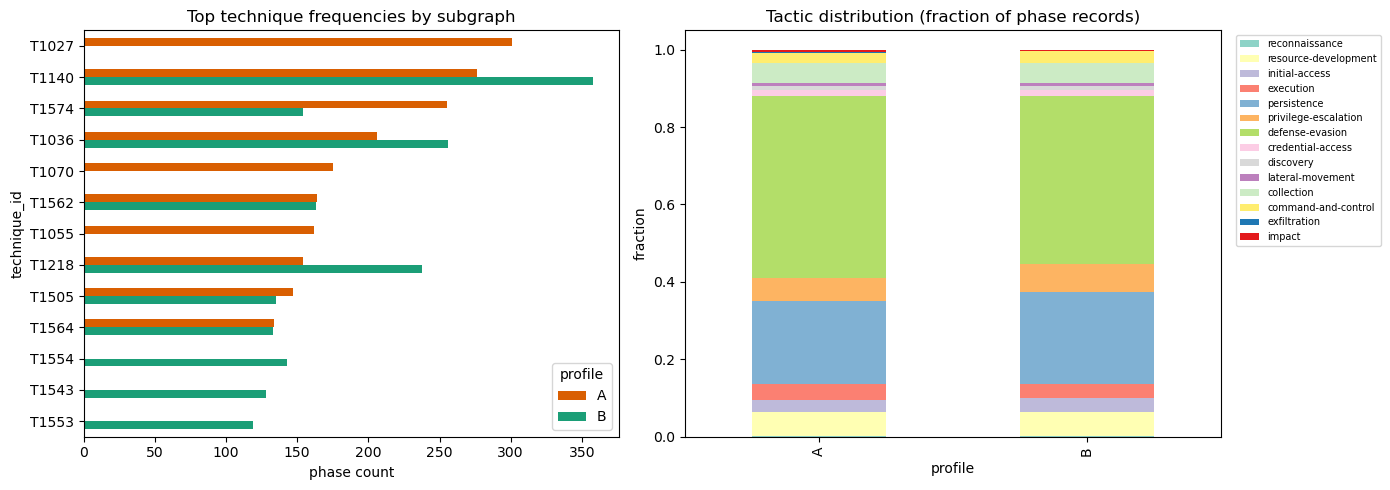

In [7]:
tstats = stats.dropna(subset=["technique_id"]).copy()
tstats["tactic"] = tstats["technique_id"].map(
    lambda t: gap.nodes[t].primary_tactic if t in gap.nodes else "unknown"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 — top-10 technique frequencies
top10 = (
    tstats.groupby(["profile", "technique_id"]).size().rename("count").reset_index()
    .sort_values(["profile", "count"], ascending=[True, False])
    .groupby("profile").head(10)
)
order = top10.pivot(index="technique_id", columns="profile", values="count").fillna(0)
order = order.sort_values(by=list(order.columns), ascending=False)
order.plot.barh(ax=axes[0], color=["#d95f02", "#1b9e77"])
axes[0].invert_yaxis()
axes[0].set_title("Top technique frequencies by subgraph")
axes[0].set_xlabel("phase count")

# Panel 2 — tactic distribution (stacked by profile)
tac = tstats.groupby(["profile", "tactic"]).size().unstack(fill_value=0)
tac = tac.div(tac.sum(axis=1), axis=0).loc[:, [t for t in TACTIC_ORDER if t in tac.columns]]
tac.plot.bar(stacked=True, ax=axes[1], color=TACTIC_PALETTE[: tac.shape[1]])
axes[1].set_title("Tactic distribution (fraction of phase records)")
axes[1].set_ylabel("fraction")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

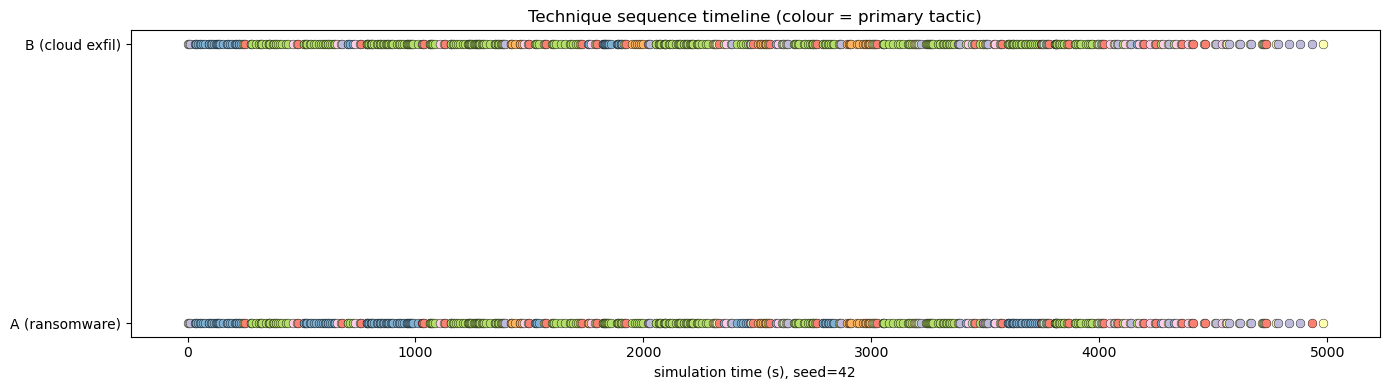

In [8]:
# Panel 3 — technique sequence strip plot for one representative seed per profile
seed = SEEDS[0]
fig, ax = plt.subplots(figsize=(14, 4))
for y_offset, tag in enumerate(("A", "B")):
    seq = stats[(stats.profile == tag) & (stats.scheme == "no_mtd") & (stats.seed == seed)]
    seq = seq.dropna(subset=["technique_id"]).reset_index(drop=True)
    for _, r in seq.iterrows():
        tid = r.technique_id
        tactic = gap.nodes[tid].primary_tactic if tid in gap.nodes else "unknown"
        colour = (
            TACTIC_PALETTE[TACTIC_ORDER.index(tactic)] if tactic in TACTIC_ORDER else "#888"
        )
        ax.scatter(r.start_time, y_offset, color=colour, s=40, edgecolor="black", linewidth=0.3)
ax.set_yticks([0, 1])
ax.set_yticklabels(["A (ransomware)", "B (cloud exfil)"])
ax.set_xlabel(f"simulation time (s), seed={seed}")
ax.set_title("Technique sequence timeline (colour = primary tactic)")
plt.tight_layout()
plt.show()

In [9]:
# Panel 4 — Jaccard similarity of technique sets
def _tset(tag, scheme, seed):
    sel = stats[(stats.profile == tag) & (stats.scheme == scheme) & (stats.seed == seed)]
    return set(sel["technique_id"].dropna())

def _jaccard(a, b):
    if not a and not b:
        return float("nan")
    return len(a & b) / len(a | b)

rows = []
for s in SEEDS:
    a = _tset("A", "no_mtd", s)
    b = _tset("B", "no_mtd", s)
    rows.append({"seed": s, "|A|": len(a), "|B|": len(b), "|A∩B|": len(a & b), "jaccard": _jaccard(a, b)})
jac = pd.DataFrame(rows)
jac

,seed,|A|,|B|,|A∩B|,jaccard
0,42,57,53,50,0.833333
1,123,50,47,38,0.644068
2,456,49,49,42,0.750000


## 6. Outcome-level comparison

Compromise-ratio distribution, time-to-first-compromise, and MTTC under `no_mtd` vs `random`.

/tmp/ipykernel_58039/1424005350.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sub[sub.profile == "A"][metric].dropna(),
/tmp/ipykernel_58039/1424005350.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sub[sub.profile == "A"][metric].dropna(),


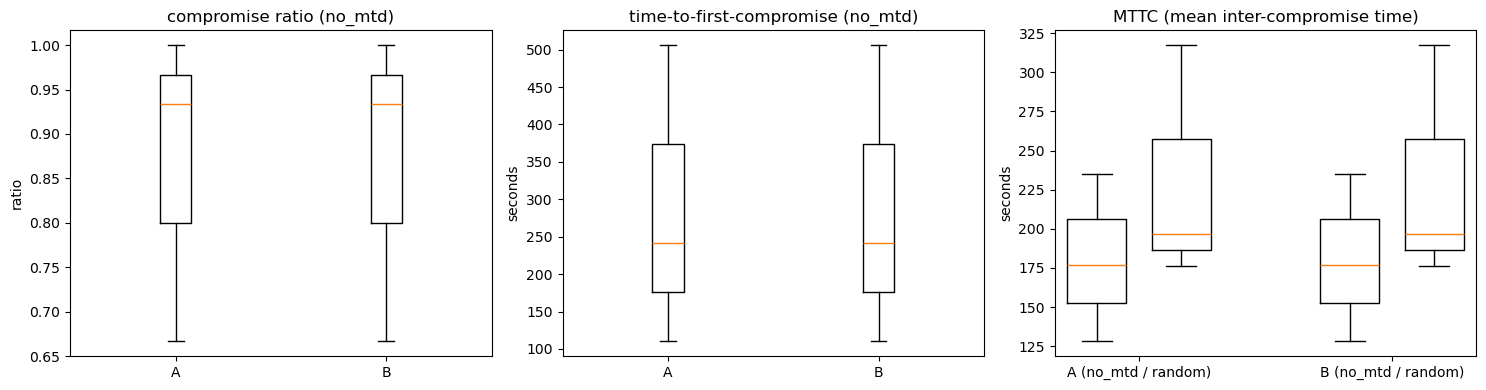

In [10]:
outcomes = (
    stats.groupby(["profile", "scheme", "seed"])
    .agg(
        compromise_ratio=("cumulative_compromised_hosts", "max"),
        time_to_first=("compromise_host", lambda col: stats.loc[col.index][col != "None"]["finish_time"].min() if (col != "None").any() else np.nan),
        exploit_durations=("duration", lambda d: d.sum()),
    )
    .reset_index()
)
outcomes["compromise_ratio"] = outcomes["compromise_ratio"] / NETWORK_PARAMS["total_nodes"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Compromise ratio
for ax, metric, title, ylabel in [
    (axes[0], "compromise_ratio", "compromise ratio (no_mtd)", "ratio"),
    (axes[1], "time_to_first", "time-to-first-compromise (no_mtd)", "seconds"),
]:
    sub = outcomes[outcomes.scheme == "no_mtd"]
    ax.boxplot([sub[sub.profile == "A"][metric].dropna(),
                sub[sub.profile == "B"][metric].dropna()], labels=["A", "B"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)

# MTTC: mean time between compromise events per run, no_mtd vs random
mttc = (
    stats[(stats["compromise_host"] != "None")]
    .sort_values(["profile", "scheme", "seed", "finish_time"])
    .groupby(["profile", "scheme", "seed"])["finish_time"]
    .agg(lambda s: s.diff().mean() if len(s) > 1 else np.nan)
    .reset_index(name="mttc")
)
for i, tag in enumerate(["A", "B"]):
    sub = mttc[mttc.profile == tag]
    positions = [i * 3 + 1, i * 3 + 2]
    axes[2].boxplot([sub[sub.scheme == "no_mtd"]["mttc"].dropna(),
                     sub[sub.scheme == "random"]["mttc"].dropna()],
                    positions=positions, widths=0.7)
axes[2].set_xticks([1.5, 4.5])
axes[2].set_xticklabels(["A (no_mtd / random)", "B (no_mtd / random)"])
axes[2].set_title("MTTC (mean inter-compromise time)")
axes[2].set_ylabel("seconds")
plt.tight_layout()
plt.show()

## 7. Replay animation

Tier 1 visualiser — three panels (network, GAP subgraph, event timeline) synchronised to a
representative event log. One frame per event, so dead time is skipped.

KeyboardInterrupt: 

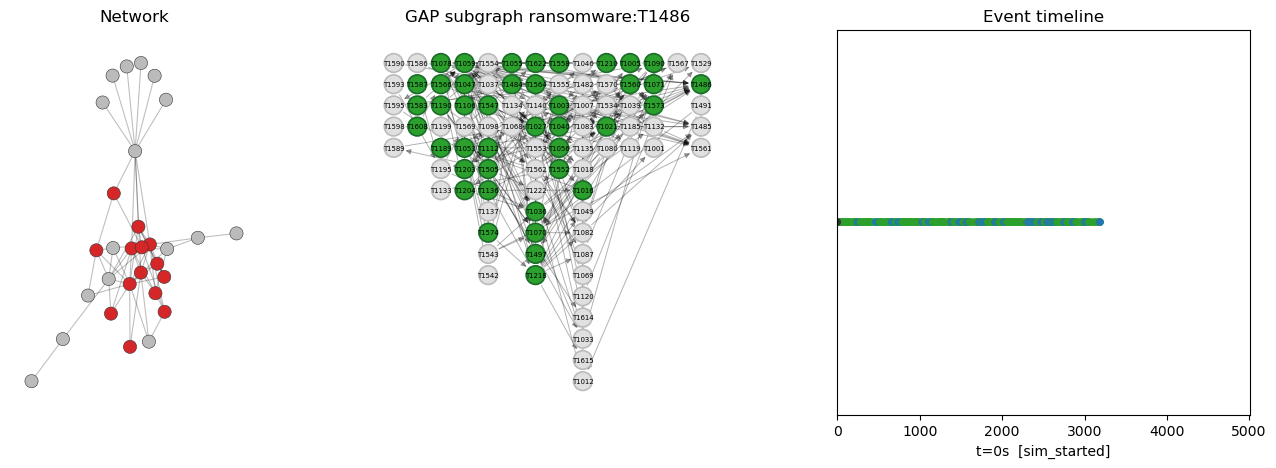

In [11]:
# Pick one representative run
replay_key = ("A", "no_mtd", SEEDS[0])
events = event_logs[replay_key]

# Rebuild the network graph once for layout
random.seed(42)
np.random.seed(42)
_layout_net = TimeNetwork(**NETWORK_PARAMS)
net_graph = _layout_net.graph.copy()
pos_net = nx.spring_layout(net_graph, seed=7)

# GAP panel graph
view = view_a
gap_graph = nx.DiGraph()
for tid in view.node_set:
    node = gap.nodes[tid]
    gap_graph.add_node(tid, layer=node.tactic_layer, tactic=node.primary_tactic, label=tid)
for (s, t) in view.edge_set:
    gap_graph.add_edge(s, t)
# Layered layout by tactic_layer
layer_counts = {}
pos_gap = {}
for tid, data in gap_graph.nodes(data=True):
    layer = data["layer"]
    y = layer_counts.get(layer, 0)
    pos_gap[tid] = (layer, -y)
    layer_counts[layer] = y + 1

# Down-sample events if too many
MAX_FRAMES = 400
if len(events) > MAX_FRAMES:
    step = len(events) // MAX_FRAMES
    events_for_play = events[::step]
else:
    events_for_play = events

compromised = set()
executing = None
executed = set()
interrupted_techniques = set()
mtd_active = False

fig, (ax_net, ax_gap, ax_time) = plt.subplots(
    1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.2, 1.8, 2.0]}
)
fig.subplots_adjust(wspace=0.3)

def draw_static():
    ax_net.set_title("Network")
    ax_net.axis("off")
    nx.draw_networkx_edges(net_graph, pos_net, ax=ax_net, alpha=0.25, width=0.8)
    ax_gap.set_title(f"GAP subgraph {profile_a.selector_tag}")
    ax_gap.axis("off")
    nx.draw_networkx_edges(gap_graph, pos_gap, ax=ax_gap, alpha=0.3, arrows=True, arrowsize=8, width=0.7)
    ax_time.set_title("Event timeline")
    ax_time.set_xlabel("sim time (s)")

draw_static()

def node_colours_net():
    colours = []
    for n in net_graph.nodes:
        if n in compromised:
            colours.append("#d62728")
        else:
            colours.append("#bbbbbb")
    return colours

def node_colours_gap():
    colours, edges = [], []
    for tid in gap_graph.nodes:
        if tid == executing:
            colours.append("#1f77b4"); edges.append("#1f77b4")
        elif tid in executed:
            colours.append("#2ca02c"); edges.append("#1b6b2b")
        else:
            colours.append("#e0e0e0"); edges.append("#bbbbbb")
        if tid in interrupted_techniques:
            edges[-1] = "#d62728"
    return colours, edges

timeline_colour = {
    "phase_started": "#1f77b4", "phase_completed": "#2ca02c",
    "host_compromised": "#d62728", "mtd_deployed": "#ff7f0e",
    "mtd_completed": "#ffbb78", "attack_interrupted": "#9467bd",
    "sim_started": "#333", "sim_ended": "#333",
}

t_points, c_points = [], []

def step(i):
    global executing, mtd_active
    ev = events_for_play[i]
    etype = ev["type"]
    if etype == "phase_started":
        executing = ev.get("technique_id")
    elif etype == "phase_completed":
        if ev.get("technique_id"):
            if ev.get("meta", {}).get("interrupted"):
                interrupted_techniques.add(ev["technique_id"])
            else:
                executed.add(ev["technique_id"])
        executing = None
    elif etype == "host_compromised":
        if ev.get("host_id") is not None:
            compromised.add(ev["host_id"])
    elif etype == "mtd_deployed":
        mtd_active = True
    elif etype == "mtd_completed":
        mtd_active = False

    # redraw
    ax_net.clear(); ax_gap.clear(); ax_time.clear()
    draw_static()
    nx.draw_networkx_nodes(net_graph, pos_net, ax=ax_net, node_color=node_colours_net(),
                           node_size=90, edgecolors="#333", linewidths=0.4)
    if mtd_active:
        ax_net.set_title("Network (MTD active)", color="#ff7f0e")
    colours, edges = node_colours_gap()
    nx.draw_networkx_nodes(gap_graph, pos_gap, ax=ax_gap, node_color=colours,
                           edgecolors=edges, node_size=180, linewidths=1.2)
    nx.draw_networkx_labels(gap_graph, pos_gap, ax=ax_gap, font_size=5)

    t_points.append(ev["t"])
    c_points.append(timeline_colour.get(etype, "#888"))
    ax_time.scatter(t_points, [0] * len(t_points), c=c_points, s=18)
    ax_time.axvline(ev["t"], color="#333", linewidth=0.7)
    ax_time.set_yticks([])
    if events_for_play:
        ax_time.set_xlim(events_for_play[0]["t"] - 10, events_for_play[-1]["t"] + 10)
    ax_time.set_xlabel(f"t={ev['t']:.0f}s  [{etype}]")

ani = manim.FuncAnimation(fig, step, frames=len(events_for_play), interval=150, repeat=False)
HTML(ani.to_jshtml())

## Summary

- **What changed**: GAP-subgraph attacker profile wired through `AttackOperation`; new event log;
  `technique_id` column on attack stats.
- **What this demonstrates**: two subgraphs (ransomware vs cloud-exfil) produce measurably
  different technique distributions and tactic coverage in the same network, under the same
  scalar attacker parameters.
- **Deferred**: DDQN retraining, defender observation upgrade, Attack Flow AND/OR preconditions,
  per-technique duration modulation, Caldera emulation.
- **Open architectural question for the meeting**: tactic-level vs technique-level agent-visible
  action space for the DDQN.
